In [ ]:
#載入套件
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import csv

In [6]:
files = ["005/005-1.csv", "007/007-1.csv", "008/008-1.csv", "009/009-1.csv", "010/010-1.csv"] #讀取檔案
labels = ["005", "007", "008", "009", "010"]  #將檔案編號

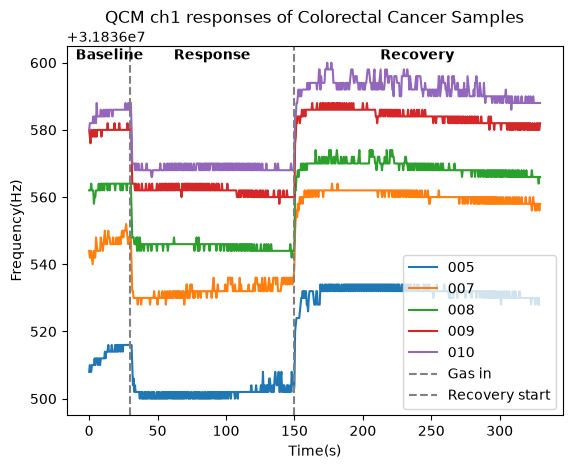

In [ ]:
count = 0 #起始為0
for file in files:
    data = pd.read_csv(file, encoding="utf-8") 
    data["datetime"] = pd.to_datetime(data["datetime"])  #讀取檔案欄位名為datetime的欄
    data["time_sec"] = (data["datetime"]-data["datetime"].iloc[0]).dt.total_seconds() #僅取秒作為x軸
    frequency = data["ch1"] #僅取每個檔案的ch1
    
    plt.plot(data["time_sec"], frequency, label=labels[count]) #在圖表上的x軸印出秒(x)，y軸印出頻率(Hz)
    count+=1 #每讀完一個檔案+1，進行label中的下一個檔案的讀取

prep = data[data["step"]=="Prep"] #定義檔案中step的prep階段
measure = data[data["step"] == "Measure"] #定義檔案中step的Measure階段
clean = data[data["step"] == "Clean"] #定義檔案中step的Clean階段


baseline_start = prep["time_sec"].iloc[0] #在prep階段的第一筆時間資料設為baseline的開始
gas_in_time = measure["time_sec"].iloc[0] #在measure階段的第一筆時間資料設為進氣的開始
recovery_start = clean["time_sec"].iloc[0] #在clean階段的第一筆時間資料設為recovery的開始
recovery_end = clean["time_sec"].iloc[-1] #在clean階段的最後一筆時間資料設為recovery的結束

#為標示實驗階段設置標籤
baseline_middle = gas_in_time /2 #baseline階段標籤位在進氣時刻前的1/2
response_middle = (gas_in_time + recovery_start) /2 #response階段標籤位在(進氣時刻+recovery開始)的1/2
recovery_middle = (recovery_start + recovery_end) /2 #recovery階段標籤位在(recovery開始+recovery結束)的1/2

#畫出圖表
y_min, y_max = plt.ylim() #取得y軸最小及最大值
y_text = y_max-5 #在y軸最大值-5處設置標籤

plt.text(
    baseline_middle,  #劃出baseline標籤
    y_text, #位置
    "Baseline", #文字內容
    ha="center",  #置中對齊
    va="bottom", #對齊底部
    fontweight="bold", #文字粗體
    color="black" #文字黑色
)

plt.text(
    response_middle, #劃出response標籤
    y_text, #位置
    "Response", #文字內容
    ha="center", #置中對齊
    va="bottom", #對齊底部
    fontweight="bold", #文字粗體
    color="black" #文字黑色
)

plt.text(
    recovery_middle, #劃出recovery標籤
    y_text, #位置
    "Recovery", #文字內容
    ha="center", #置中對齊
    va="bottom", #對齊底部
    fontweight="bold", #文字粗體
    color="black" #文字黑色
)
plt.axvline(gas_in_time, linestyle="--", label="Gas in", color="grey") #劃出灰色虛線，用以表達進氣時刻
plt.axvline(recovery_start, linestyle="--", label="Recovery start", color="grey") #劃出灰色虛線，用以表達recovery開始

plt.xlabel("Time(s)") #設時間為x軸座標
plt.ylabel("Frequency(Hz)") #設頻率為y軸座標
plt.title("QCM ch1 responses of Colorectal Cancer Samples") #設定標題
plt.legend() #顯示圖例
plt.savefig("QCM ch1 responses of Colorectal Cancer Samples.png") #另存為png檔
plt.show() #顯示圖表
